## TESTS PRELIMINARES

In [ ]:
# Vemos si tenemos instalado CUDA
! dir /usr/local/

bin    cuda	cuda-12.5	  etc	 include  libexec     man  sbin   src
colab  cuda-12	dist_metrics.pxd  games  lib	  LICENSE.md  opt  share


In [ ]:
!nvidia-smi

Tue Jun 24 19:33:29 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Para checar la versión del compilador de CUDA
! nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


In [ ]:
import torch
print(torch.cuda.is_available())  # Devuelve True si hay GPU
print(torch.cuda.get_device_name(0))  # Nombre de la GPU

True
Tesla T4


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))  # Lista las GPUs disponibles

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# SERIAL
%%writefile HelloCUDA_serial.cpp
#include <stdio.h>
#include <time.h> // Include for time measurement

int main(void){
    clock_t start_time, end_time;
    double cpu_time_used;

    start_time = clock(); // Start timing

    for (int i = 0; i < 20000; ++i) { // Loop 2000 times
        printf("\nHello World\n");
    }

    end_time = clock(); // End timing
    cpu_time_used = ((double) (end_time - start_time)) / CLOCKS_PER_SEC; // Calculate time in seconds

    printf("\nExecution time: %f seconds\n", cpu_time_used); // Print execution time

    return(0);
}

Writing HelloCUDA_serial.cpp


In [ ]:
!g++ -o HelloCUDA_serial HelloCUDA_serial.cpp

In [ ]:
!./HelloCUDA_serial

Streaming output truncated to the last 5000 lines.

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World

Hello World


In [ ]:
%%writefile HelloCUDA.cu
#include <stdio.h>
#include <cuda_runtime.h>
#include <time.h> // Include for time measurement

__global__ void helloCUDA(float e){
    printf("Soy el hilo %d del bloque %d con valor e=%f\n",threadIdx.x,blockIdx.x,e);
    //printf("\nHello World\n"); // Commenting out the original print
}

int main(void){
    clock_t start_time, end_time;
    double cuda_time_used;

    start_time = clock(); // Start timing

    helloCUDA<<<10,20>>>(2.71828f); // Using 1000 blocks and 20 threads as in the provided code

    cudaDeviceSynchronize(); // Wait for the kernel to finish

    end_time = clock(); // End timing
    cuda_time_used = ((double) (end_time - start_time)) / CLOCKS_PER_SEC; // Calculate time in seconds

    printf("\nExecution time: %f seconds\n", cuda_time_used); // Print execution time


    cudaDeviceReset();
    return(0);
}

Writing HelloCUDA.cu


In [ ]:
# Compilando con nvcc
! nvcc -arch=sm_75 HelloCUDA.cu -o HelloCUDA

In [ ]:
# Ejecutando el programa
! ./HelloCUDA

Soy el hilo 0 del bloque 4 con valor e=2.718280
Soy el hilo 1 del bloque 4 con valor e=2.718280
Soy el hilo 2 del bloque 4 con valor e=2.718280
Soy el hilo 3 del bloque 4 con valor e=2.718280
Soy el hilo 4 del bloque 4 con valor e=2.718280
Soy el hilo 5 del bloque 4 con valor e=2.718280
Soy el hilo 6 del bloque 4 con valor e=2.718280
Soy el hilo 7 del bloque 4 con valor e=2.718280
Soy el hilo 8 del bloque 4 con valor e=2.718280
Soy el hilo 9 del bloque 4 con valor e=2.718280
Soy el hilo 10 del bloque 4 con valor e=2.718280
Soy el hilo 11 del bloque 4 con valor e=2.718280
Soy el hilo 12 del bloque 4 con valor e=2.718280
Soy el hilo 13 del bloque 4 con valor e=2.718280
Soy el hilo 14 del bloque 4 con valor e=2.718280
Soy el hilo 15 del bloque 4 con valor e=2.718280
Soy el hilo 16 del bloque 4 con valor e=2.718280
Soy el hilo 17 del bloque 4 con valor e=2.718280
Soy el hilo 18 del bloque 4 con valor e=2.718280
Soy el hilo 19 del bloque 4 con valor e=2.718280
Soy el hilo 0 del bloque 9 con

In [ ]:
%%writefile conociendo_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <cuda_runtime.h>
#include <device_launch_parameters.h>

__global__ void idThreads_kernel(int *block_dev,
                                 int *threadLocal_dev,
                                 int *warp_dev,
                                 int *threadGlobal_dev){
    int threadGlobal_idx = (blockIdx.x * blockDim.x) + threadIdx.x;

    block_dev[threadGlobal_idx] = blockIdx.x;
    threadLocal_dev[threadGlobal_idx] = threadIdx.x;
    warp_dev[threadGlobal_idx] = threadGlobal_idx / warpSize;
    threadGlobal_dev[threadGlobal_idx] = threadGlobal_idx;
}

#define TAM 128
// #define TAM 140

int main(void){
    int num_blocks = 4;
    int num_threads = 32;
    // int num_threads = 35;

    // Arreglos estáticos en el host
    int block_host[TAM];
    int threadLocal_host[TAM];
    int warp_host[TAM];
    int threadGlobal_host[TAM];

    // Arreglos dinámicos en el device
    int *block_dev;
    int *threadLocal_dev;
    int *warp_dev;
    int *threadGlobal_dev;

    // Crear memoria dinámica en el device
    size_t TAM_Bytes_int = TAM * sizeof(int);
    cudaMalloc((void**)&block_dev, TAM_Bytes_int);
    cudaMalloc((void**)&threadLocal_dev, TAM_Bytes_int);
    cudaMalloc((void**)&warp_dev, TAM_Bytes_int);
    cudaMalloc((void**)&threadGlobal_dev, TAM_Bytes_int);

    // Inicializar con -1 en el device
    cudaMemset(threadGlobal_dev, -1, TAM_Bytes_int);
    cudaMemset(threadLocal_dev, -1, TAM_Bytes_int);
    cudaMemset(warp_dev, -1, TAM_Bytes_int);
    cudaMemset(block_dev, -1, TAM_Bytes_int);

    // Ejecutar Kernel
    idThreads_kernel<<<num_blocks, num_threads>>>(block_dev, threadLocal_dev, warp_dev, threadGlobal_dev);

    // Copiar memoria desde el device al host
    cudaMemcpy(block_host, block_dev, TAM_Bytes_int, cudaMemcpyDeviceToHost);
    cudaMemcpy(threadLocal_host, threadLocal_dev, TAM_Bytes_int, cudaMemcpyDeviceToHost);
    cudaMemcpy(warp_host, warp_dev, TAM_Bytes_int, cudaMemcpyDeviceToHost);
    cudaMemcpy(threadGlobal_host, threadGlobal_dev, TAM_Bytes_int, cudaMemcpyDeviceToHost);

    // Imprimir resultados
    printf("IdxGlobal\tBlock\tWarp\tIdxLocal\n");
    for(int i = 0; i < num_blocks * num_threads; i++){
        printf("%d\t\t%d\t%d\t\t%d\n",
            threadGlobal_host[i],
            block_host[i],
            warp_host[i],
            threadLocal_host[i]);
    }

    // Liberar memoria
    cudaFree(block_dev);
    cudaFree(threadLocal_dev);
    cudaFree(warp_dev);
    cudaFree(threadGlobal_dev);

    return 0;
}


Writing conociendo_cuda.cu


In [ ]:
!nvcc -arch=sm_75 conociendo_cuda.cu -o conociendo_cuda

In [ ]:
!./conociendo_cuda

IdxGlobal	Block	Warp	IdxLocal
0		0	0		0
1		0	0		1
2		0	0		2
3		0	0		3
4		0	0		4
5		0	0		5
6		0	0		6
7		0	0		7
8		0	0		8
9		0	0		9
10		0	0		10
11		0	0		11
12		0	0		12
13		0	0		13
14		0	0		14
15		0	0		15
16		0	0		16
17		0	0		17
18		0	0		18
19		0	0		19
20		0	0		20
21		0	0		21
22		0	0		22
23		0	0		23
24		0	0		24
25		0	0		25
26		0	0		26
27		0	0		27
28		0	0		28
29		0	0		29
30		0	0		30
31		0	0		31
32		1	1		0
33		1	1		1
34		1	1		2
35		1	1		3
36		1	1		4
37		1	1		5
38		1	1		6
39		1	1		7
40		1	1		8
41		1	1		9
42		1	1		10
43		1	1		11
44		1	1		12
45		1	1		13
46		1	1		14
47		1	1		15
48		1	1		16
49		1	1		17
50		1	1		18
51		1	1		19
52		1	1		20
53		1	1		21
54		1	1		22
55		1	1		23
56		1	1		24
57		1	1		25
58		1	1		26
59		1	1		27
60		1	1		28
61		1	1		29
62		1	1		30
63		1	1		31
64		2	2		0
65		2	2		1
66		2	2		2
67		2	2		3
68		2	2		4
69		2	2		5
70		2	2		6
71		2	2		7
72		2	2		8
73		2	2		9
74		2	2		10
75		2	2		11
76		2	2		12
77		2	2		13
78		2	2		14
79		2	2		15
80		2	2		16
81		2	2		17
82		2	2		18
83		2	2		19
84

#ACTIVIDAD SUMA DE VECTORES CUDA VS CPU

##CUDA

In [ ]:
#Ejemplo_2 suma_vectores
%%writefile suma_vectores.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

// Kernel para sumar dos vectores
__global__ void Suma_vectores(float *c_d, float *a_d, float *b_d, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        c_d[idx] = a_d[idx] + b_d[idx];
    }
}

int main(void) {
    FILE *archivo = fopen("tiempos_gpu.txt", "w");
    if (!archivo) {
        printf("Error abriendo archivo de salida\n");
        return 1;
    }
    fprintf(archivo, "# Tamaño\tTiempo_GPU_ms\n");

    for (int exp = 1; exp <= 8; ++exp) {
        int N = (int)pow(10, exp);
        size_t size = N * sizeof(float);

        // Reserva de memoria en host
        float *a_h = (float*)malloc(size);
        float *b_h = (float*)malloc(size);
        float *c_h = (float*)malloc(size);

        // Inicialización
        for (int i = 0; i < N; ++i) {
            a_h[i] = rand() % 100 + 1.0f;
            b_h[i] = rand() % 100 + 1.0f;
        }

        // Reserva en device
        float *a_d, *b_d, *c_d;
        cudaMalloc((void**)&a_d, size);
        cudaMalloc((void**)&b_d, size);
        cudaMalloc((void**)&c_d, size);

        // Copia de datos al device
        cudaMemcpy(a_d, a_h, size, cudaMemcpyHostToDevice);
        cudaMemcpy(b_d, b_h, size, cudaMemcpyHostToDevice);

        // Configuración de ejecución
        int block_size = 256;
        int n_blocks = (N + block_size - 1) / block_size;

        // Medición con eventos
        cudaEvent_t start, stop;
        cudaEventCreate(&start);
        cudaEventCreate(&stop);

        cudaEventRecord(start);
        Suma_vectores<<<n_blocks, block_size>>>(c_d, a_d, b_d, N);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);

        float tiempo_gpu = 0.0f;
        cudaEventElapsedTime(&tiempo_gpu, start, stop);

        // Registro
        printf("N = %d\tTiempo GPU = %.4f ms\n", N, tiempo_gpu);
        fprintf(archivo, "%d\t%.4f\n", N, tiempo_gpu);

        // Liberación
        free(a_h); free(b_h); free(c_h);
        cudaFree(a_d); cudaFree(b_d); cudaFree(c_d);
        cudaEventDestroy(start);
        cudaEventDestroy(stop);
    }

    fclose(archivo);
    return 0;
}


Overwriting suma_vectores.cu


In [ ]:
! nvcc suma_vectores.cu -o suma_vectores

In [ ]:
! ./suma_vectores

N = 10	Tiempo GPU = 55.3844 ms
N = 100	Tiempo GPU = 0.0051 ms
N = 1000	Tiempo GPU = 0.0041 ms
N = 10000	Tiempo GPU = 0.0029 ms
N = 100000	Tiempo GPU = 0.0026 ms
N = 1000000	Tiempo GPU = 0.0025 ms
N = 10000000	Tiempo GPU = 0.0026 ms
N = 100000000	Tiempo GPU = 0.0031 ms


##CPU

In [ ]:
%%writefile suma_vectores_cpu.cpp
#include <iostream>
#include <vector>
#include <chrono>
#include <fstream>
#include <cmath>
#include <cstdlib>

int main() {
    std::ofstream archivo("tiempos.txt");  // Archivo de salida
    if (!archivo.is_open()) {
        std::cerr << "No se pudo abrir el archivo de salida.\n";
        return 1;
    }

    archivo << "# Tamaño\tTiempo_CPU_ms\n";

    for (int exp = 1; exp <= 8; ++exp) {
        size_t N = static_cast<size_t>(pow(10, exp));

        std::vector<float> a(N), b(N), c(N);

        // Inicializar vectores con valores aleatorios entre 1 y 100
        for (size_t i = 0; i < N; ++i) {
            a[i] = rand() % 100 + 1.0f;
            b[i] = rand() % 100 + 1.0f;
        }

        auto start = std::chrono::high_resolution_clock::now();

        for (size_t i = 0; i < N; ++i) {
            c[i] = a[i] + b[i];
        }

        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double, std::milli> duration_ms = end - start;

        std::cout << "N = " << N << "\tTiempo CPU = " << duration_ms.count() << " ms\n";
        archivo << N << "\t" << duration_ms.count() << "\n";
    }

    archivo.close();
    return 0;
}

Overwriting suma_vectores_cpu.cpp


In [ ]:
!g++ suma_vectores_cpu.cpp -o suma_vectores_cpu

In [ ]:
!./suma_vectores_cpu

N = 10	Tiempo CPU = 0.000209 ms
N = 100	Tiempo CPU = 0.001062 ms
N = 1000	Tiempo CPU = 0.006856 ms
N = 10000	Tiempo CPU = 0.068104 ms
N = 100000	Tiempo CPU = 0.717862 ms
N = 1000000	Tiempo CPU = 7.35765 ms
N = 10000000	Tiempo CPU = 75.4798 ms
N = 100000000	Tiempo CPU = 767.371 ms


## PYTHON PARA GRAFICAR

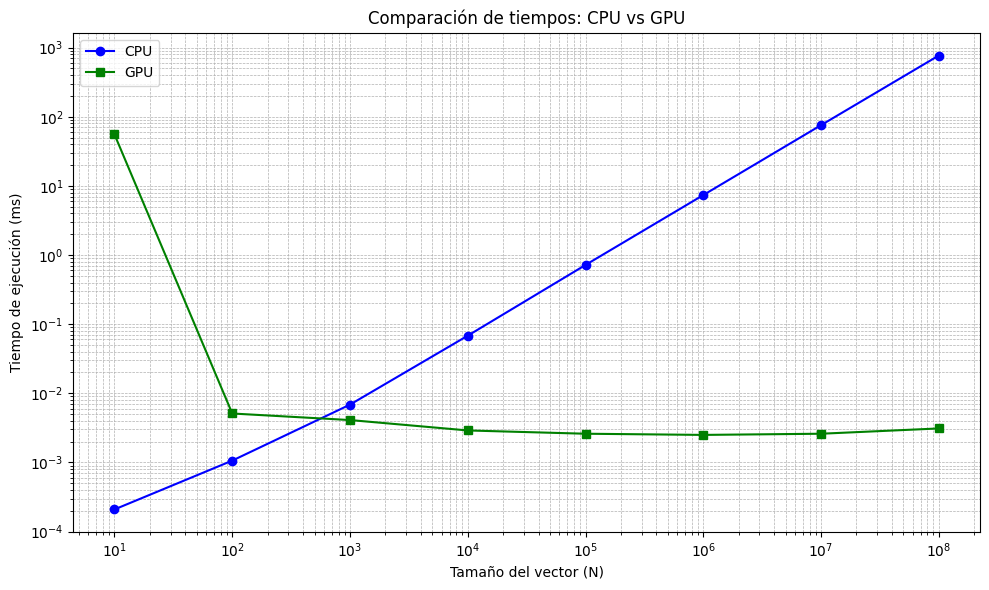

In [ ]:
import matplotlib.pyplot as plt

# Leer tiempos CPU
n_cpu, t_cpu = [], []
with open("tiempos.txt", "r") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split()
        n_cpu.append(int(parts[0]))
        t_cpu.append(float(parts[1]))

# Leer tiempos GPU
n_gpu, t_gpu = [], []
with open("tiempos_gpu.txt", "r") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split()
        n_gpu.append(int(parts[0]))
        t_gpu.append(float(parts[1]))

# Verificación opcional
assert n_cpu == n_gpu, "Los tamaños de vector no coinciden entre CPU y GPU"

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(n_cpu, t_cpu, 'o-', label="CPU", color='blue')
plt.plot(n_gpu, t_gpu, 's-', label="GPU", color='green')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Tamaño del vector (N)")
plt.ylabel("Tiempo de ejecución (ms)")
plt.title("Comparación de tiempos: CPU vs GPU")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("comparacion_cpu_vs_gpu.png")
plt.show()
